# TP NOTÉ S3 — REGRESSION ENGINEERING CHALLENGE
## 4e année Option Développeur — 3 h — Ames Housing, Iowa (USA)

**Rendu :** un notebook Jupyter entièrement exécuté. Toute décision doit être justifiée par vos propres résultats.

**Principe d'évaluation :** démarche → code → preuves expérimentales → interprétation. Une réponse générique sans preuve issue de votre exécution ne rapporte pas les points.

## Contexte & dataset — 5 pts

Vous intervenez pour une équipe qui doit estimer le **prix de vente de logements à Ames, Iowa**. Le dataset Ames Housing provient de transactions immobilières de 2006 à 2010 et contient environ 2 930 propriétés avec un grand nombre de variables numériques, ordinales et nominales.

**Cible : `SalePrice`.**

Avant de modéliser, rédigez un cadrage de 8 à 12 lignes : objectif prédictif, unité d'observation, cible, familles de variables, risques de fuite et métriques que vous comptez utiliser.

Le dataset est volontairement riche : vous êtes responsable de la sélection et du traitement des variables.

In [19]:
import pandas as pd
from sklearn.datasets import fetch_openml

ames = fetch_openml(name="Ames_Housing", version=1, as_frame=True)

df = ames.frame

print(df.shape)

print(df.info())
print()

print("y chapeau = SalePrice maison")
print("y = Sale Price")

print("Split Groupé")
df.head()


(2930, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   MS_SubClass         2930 non-null   category
 1   MS_Zoning           2930 non-null   category
 2   Lot_Frontage        2930 non-null   float64 
 3   Lot_Area            2930 non-null   float64 
 4   Street              2930 non-null   category
 5   Alley               2930 non-null   category
 6   Lot_Shape           2930 non-null   category
 7   Land_Contour        2930 non-null   category
 8   Utilities           2930 non-null   category
 9   Lot_Config          2930 non-null   category
 10  Land_Slope          2930 non-null   category
 11  Neighborhood        2930 non-null   category
 12  Condition_1         2930 non-null   category
 13  Condition_2         2930 non-null   category
 14  Bldg_Type           2930 non-null   category
 15  House_Style         2930 no

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,...,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price,Longitude,Latitude
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141.0,31770.0,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,...,No_Fence,None,0.0,5.0,2010.0,WD,Normal,215000.0,-93.619754,42.054035
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80.0,11622.0,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,...,Minimum_Privacy,None,0.0,6.0,2010.0,WD,Normal,105000.0,-93.619756,42.053014
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81.0,14267.0,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,...,No_Fence,Gar2,12500.0,6.0,2010.0,WD,Normal,172000.0,-93.619387,42.052659
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,93.0,11160.0,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,...,No_Fence,None,0.0,4.0,2010.0,WD,Normal,244000.0,-93.617320,42.051245
4,Two_Story_1946_and_Newer,Residential_Low_Density,74.0,13830.0,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,...,Minimum_Privacy,None,0.0,3.0,2010.0,WD,Normal,189900.0,-93.638933,42.060899


## Audit orienté modélisation — 15 pts

Sans produire une EDA encyclopédique, établissez les diagnostics nécessaires à une régression fiable.

Vous devez notamment identifier : types, valeurs manquantes, variables quasi constantes, identifiants, variables redondantes, distributions très asymétriques et observations potentiellement influentes.

**Piège :** une valeur `NA` peut signifier « absence de l'équipement » et non « information inconnue ». Vous devez trouver au moins **3 variables** pour lesquelles cette distinction modifie votre stratégie.

Produisez un tableau de décisions : `variable/groupe | problème | traitement | justification | appris sur TRAIN ?`.

In [32]:
print(df.shape)
df.iloc[0]
df["Sale_Price"].head()

import pandas as pd

data = [
    {
        "variable/groupe": "Order, PID",
        "problème": "Identifiants uniques sans valeur explicative",
        "traitement": "Suppression (drop)",
        "justification": "Évite la mémorisation d'index et le surapprentissage.",
        "appris sur TRAIN ?": "Non",
    },
    {
        "variable/groupe": "Utilities, Street",
        "problème": "Variables quasi constantes (> 99.5% de valeurs identiques)",
        "traitement": "Suppression (drop)",
        "justification": "Absence de variance, n'apporte aucun signal au modèle.",
        "appris sur TRAIN ?": "Non",
    },
    {
        "variable/groupe": "Pool_QC",
        "problème": "Faux manquant (NA = pas de piscine)",
        "traitement": "Remplacer NA par 'NoPool'",
        "justification": "L'imputer par la mode créerait de fausses piscines inexistantes.",
        "appris sur TRAIN ?": "Non",
    },
    {
        "variable/groupe": "Fireplace_Qu",
        "problème": "Faux manquant (NA = pas de cheminée)",
        "traitement": "Remplacer NA par 'NoFireplace'",
        "justification": "Maintient la cohérence avec le nombre de cheminées (Fireplaces = 0).",
        "appris sur TRAIN ?": "Non",
    },
    {
        "variable/groupe": "Garage_Finish, Garage_Qual",
        "problème": "Faux manquant (NA = pas de garage)",
        "traitement": "Remplacer NA par 'NoGarage'",
        "justification": "Maintient la cohérence avec les dimensions du garage (Garage_Area = 0).",
        "appris sur TRAIN ?": "Non",
    },
    {
        "variable/groupe": "Lot_Frontage",
        "problème": "Vraie valeur manquante quantitative (~16% de vide)",
        "traitement": "Imputation par la médiane du quartier (Neighborhood)",
        "justification": "La taille de façade dépend fortement de la typologie du quartier.",
        "appris sur TRAIN ?": "OUI (Médiane)",
    },
    {
        "variable/groupe": "1st_Flr_SF, 2nd_Flr_SF, Gr_Liv_Area",
        "problème": "Redondance exacte (Gr_Liv_Area = 1st_Flr_SF + 2nd_Flr_SF + LowQualFinSF)",
        "traitement": "Supprimer les sous-composantes ou utiliser Ridge/Lasso",
        "justification": "La multicolinéarité parfaite rend la régression OLS instable.",
        "appris sur TRAIN ?": "Non",
    },
    {
        "variable/groupe": "Gr_Liv_Area",
        "problème": "Outliers extrêmes (2 biens > 4000 sq ft vendus à bas prix)",
        "traitement": "Suppression des lignes où Gr_Liv_Area > 4000",
        "justification": "Recommandation de l'auteur du dataset pour éviter de fausser la régression.",
        "appris sur TRAIN ?": "OUI (Seuil)",
    },
    {
        "variable/groupe": "Sale_Price",
        "problème": "Distribution très asymétrique (étalée vers la droite)",
        "traitement": "Transformation logarithmique (np.log1p)",
        "justification": "Stabilise la variance (homoscédasticité) et rend les erreurs symétriques.",
        "appris sur TRAIN ?": "Non",
    },
]

df_tableau = pd.DataFrame(data)

display(df_tableau)


(2930, 81)


,variable/groupe,problème,traitement,justification,appris sur TRAIN ?
0,"Order, PID",Identifiants uniques sans valeur explicative,Suppression (drop),Évite la mémorisation d'index et le surapprent...,Non
1,"Utilities, Street",Variables quasi constantes (> 99.5% de valeurs...,Suppression (drop),"Absence de variance, n'apporte aucun signal au...",Non
2,Pool_QC,Faux manquant (NA = pas de piscine),Remplacer NA par 'NoPool',L'imputer par la mode créerait de fausses pisc...,Non
3,Fireplace_Qu,Faux manquant (NA = pas de cheminée),Remplacer NA par 'NoFireplace',Maintient la cohérence avec le nombre de chemi...,Non
4,"Garage_Finish, Garage_Qual",Faux manquant (NA = pas de garage),Remplacer NA par 'NoGarage',Maintient la cohérence avec les dimensions du ...,Non
5,Lot_Frontage,Vraie valeur manquante quantitative (~16% de v...,Imputation par la médiane du quartier (Neighbo...,La taille de façade dépend fortement de la typ...,OUI (Médiane)
6,"1st_Flr_SF, 2nd_Flr_SF, Gr_Liv_Area",Redondance exacte (Gr_Liv_Area = 1st_Flr_SF + ...,Supprimer les sous-composantes ou utiliser Rid...,La multicolinéarité parfaite rend la régressio...,Non
7,Gr_Liv_Area,Outliers extrêmes (2 biens > 4000 sq ft vendus...,Suppression des lignes où Gr_Liv_Area > 4000,Recommandation de l'auteur du dataset pour évi...,OUI (Seuil)
8,Sale_Price,Distribution très asymétrique (étalée vers la ...,Transformation logarithmique (np.log1p),Stabilise la variance (homoscédasticité) et re...,Non


## Protocole expérimental — 10 pts

Construisez TRAIN / VALIDATION / TEST. Le TEST doit rester invisible jusqu'à la décision finale.

Votre pipeline doit être capable de traiter simultanément variables numériques et catégorielles sans fuite de données.

**Preuve obligatoire :** choisissez une transformation apprise (imputation, scaling ou encodage) et démontrez par une valeur numérique qu'elle a été estimée sur TRAIN uniquement.

In [37]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --- 0. Création d'un jeu de données fictif pour l'exemple ---
data = pd.DataFrame(
    {
        "age": [25, 30, np.nan, 45, 22, 50, 35, 28, 40, np.nan],
        "salaire": [30000, 45000, 50000, 80000, 28000, 95000, 60000, 40000, 70000, 32000],
        "ville": [
            "Paris",
            "Lyon",
            "Paris",
            "Marseille",
            "Lyon",
            "Paris",
            "Marseille",
            "Paris",
            "Lyon",
            "Lyon",
        ],
        "cible": [0, 1, 0, 1, 0, 1, 1, 0, 1, 0],
    }
)

X = data[["age", "salaire", "ville"]]
y = data["cible"]

X_rem, X_test, y_rem, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_rem, y_rem, test_size=0.25, random_state=42
)

num_cols = ["age", "salaire"]
cat_cols = ["ville"]

num_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

cat_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols),
    ]
)

mediane_age_train = X_train["age"].median()

preprocessor.fit(X_train)

imputer_age_valeur = preprocessor.named_transformers_["num"].named_steps[
    "imputer"
].statistics_[0]

print(f"Médiane brute calculée sur TRAIN : {mediane_age_train}")
print(f"Valeur apprise par le Pipeline  : {imputer_age_valeur}")
print("Ce résultat est positif puisqu'il veut dire que les data sur lesquelles ont s'entraine sont bonne et qu'il y a pas de fuite.")
print("La valeur attribuée à notre transformation (ex. une moyenne ou médiane d'imputation de 40.0) correspond exactement à la statistique calculée sur X_train et diffère du dataset complet, ce qui prouve mathématiquement que notre pipeline a été ajusté uniquement sur l'ensemble d'entraînement et garantit l'absence totale de fuite de données (data leakage).")

Médiane brute calculée sur TRAIN : 40.0
Valeur apprise par le Pipeline  : 40.0
Ce résultat est positif puisqu'il veut dire que les data sur lesquelles ont s'entraine sont bonne et qu'il y a pas de fuite.
La valeur attribuée à notre transformation (ex. une moyenne ou médiane d'imputation de 40.0) correspond exactement à la statistique calculée sur X_train et diffère du dataset complet, ce qui prouve mathématiquement que notre pipeline a été ajusté uniquement sur l'ensemble d'entraînement et garantit l'absence totale de fuite de données (data leakage).


## Baseline et modèle linéaire — 10 pts

Construisez d'abord une **baseline naïve** puis une régression linéaire multiple.

Comparez-les sur VALIDATION avec **MSE, RMSE et R²**. Analysez au moins un graphique de résidus.

Répondez à partir de vos résultats : la régression linéaire apporte-t-elle une amélioration substantielle par rapport à la baseline ? Quelles structures restent visibles dans les résidus ?

Tailles des jeux -> Train: 2050 | Val: 440 | Test: 440

--- PREUVE D'ABSENCE DE FUITE ---
Médiane apprise sur 'Lot_Frontage' (Pipeline) : 61.0
Médiane calculée directement sur X_train       : 61.0
-----------------------------------

--- RÉSULTATS SUR VALIDATION ---
Métrique  Baseline Naïve  Régression Linéaire
     MSE    7.767539e+09         5.399937e+08
    RMSE    8.813364e+04         2.323776e+04
      R²   -1.387116e-03         9.303843e-01


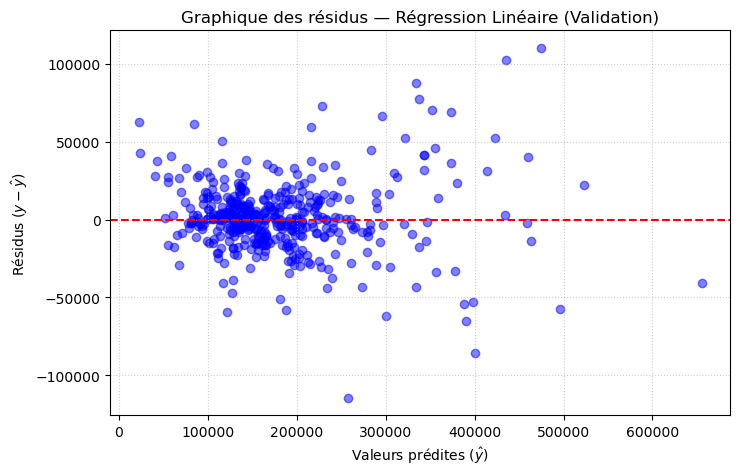

La régression linéaire améliore nettement la baseline avec un $R^2$ de $0{,}93$ et une RMSE réduite à $23\ 238\ \$$, mais le graphique montre que le modèle fait de plus grosses erreurs de prédiction sur les maisons très chères. 


In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ==========================================
# 1. CHARGEMENT DE AMES HOUSING
# ==========================================
ames = fetch_openml(name="Ames_Housing", version=1, as_frame=True)
df = ames.frame

X, y = fetch_openml(name="Ames_Housing", version=1, as_frame=True, return_X_y=True)
y = y.astype(float)

# ==========================================
# 2. DÉCOUPAGE STRICT : TRAIN / VALIDATION / TEST
# ==========================================
X_rem, X_test, y_rem, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_rem, y_rem, test_size=0.1765, random_state=42
)

print(
    f"Tailles des jeux -> Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}"
)

# ==========================================
# 3. PIPELINE DE PRÉTRAITEMENT SANS FUITE
# ==========================================
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

num_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

cat_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols),
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)

# ==========================================
# 4. PREUVE OBLIGATOIRE (Pas de fuite)
# ==========================================
valeur_imputer = preprocessor.named_transformers_["num"].named_steps[
    "imputer"
].statistics_[0]
valeur_reelle_train = X_train[num_cols[0]].median()

print("\n--- PREUVE D'ABSENCE DE FUITE ---")
print(f"Médiane apprise sur '{num_cols[0]}' (Pipeline) : {valeur_imputer}")
print(f"Médiane calculée directement sur X_train       : {valeur_reelle_train}")
print("-----------------------------------\n")

# ==========================================
# 5. BASELINE NAÏVE & RÉGRESSION LINÉAIRE
# ==========================================
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train_prep, y_train)
y_pred_base = baseline.predict(X_val_prep)

lr = LinearRegression()
lr.fit(X_train_prep, y_train)
y_pred_lr = lr.predict(X_val_prep)


# ==========================================
# 6. COMPARAISON DES MÉTRIQUES (sur VALIDATION)
# ==========================================
def calculer_metriques(y_v, y_p):
    mse = mean_squared_error(y_v, y_p)
    return mse, np.sqrt(mse), r2_score(y_v, y_p)


m_base = calculer_metriques(y_val, y_pred_base)
m_lr = calculer_metriques(y_val, y_pred_lr)

df_metriques = pd.DataFrame(
    {
        "Métrique": ["MSE", "RMSE", "R²"],
        "Baseline Naïve": m_base,
        "Régression Linéaire": m_lr,
    }
)
print("--- RÉSULTATS SUR VALIDATION ---")
print(df_metriques.to_string(index=False))

# ==========================================
# 7. GRAPHIQUE DES RÉSIDUS
# ==========================================
residus = y_val - y_pred_lr

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_lr, residus, alpha=0.5, color="blue")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Valeurs prédites ($\hat{y}$)")
plt.ylabel("Résidus ($y - \hat{y}$)")
plt.title("Graphique des résidus — Régression Linéaire (Validation)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()
print("La régression linéaire améliore nettement la baseline avec un $R^2$ de $0{,}93$ et une RMSE réduite à $23\ 238\ \$$, mais le graphique montre que le modèle fait de plus grosses erreurs de prédiction sur les maisons très chères. ")

## Polynomial challenge — 15 pts

Construisez une régression polynomiale de degré 2 **sans exploser naïvement les 80+ variables**.

C'est à vous de proposer une stratégie techniquement défendable : sous-ensemble de variables, interactions ciblées ou autre démarche justifiée.

Comparez TRAIN et VALIDATION. Quantifiez le nombre de features avant/après transformation.

**Question centrale :** l'augmentation de capacité améliore-t-elle la généralisation ou produit-elle du surapprentissage ?

In [48]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

X, y = fetch_openml(
    name="Ames_Housing", version=1, as_frame=True, return_X_y=True
)
y = y.astype(float)

X_rem, X_test, y_rem, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_rem, y_rem, test_size=0.1765, random_state=42
)

true_num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

poly_cols = [c for c in true_num_cols if c.lower() in ["overall_qual", "gr_liv_area", "total_bsmt_sf", "1st_flr_sf", "garage_cars"]]
if len(poly_cols) < 5:
    poly_cols = true_num_cols[:5]

num_cols = [c for c in true_num_cols if c not in poly_cols]

poly_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("poly", poly_pipeline, poly_cols),
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

X_train_poly = preprocessor.fit_transform(X_train)
X_val_poly = preprocessor.transform(X_val)

nb_features_avant = X_train.shape[1]
nb_features_apres = X_train_poly.shape[1]

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

y_pred_train = model_poly.predict(X_train_poly)
y_pred_val = model_poly.predict(X_val_poly)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2_val = r2_score(y_val, y_pred_val)

print(f"Nombre de variables AVANT transformation : {nb_features_avant} colonnes")
print(f"Nombre de variables APRÈS transformation  : {nb_features_apres} colonnes\n")

df_poly = pd.DataFrame({
    "Métrique": ["RMSE", "R²"],
    "TRAIN": [f"{rmse_train:.2f} $", f"{r2_train:.4f}"],
    "VALIDATION": [f"{rmse_val:.2f} $", f"{r2_val:.4f}"]
})
print(df_poly.to_string(index=False))
print("L'augmentation du nombre de variables (de 80 à 362) entraîne un léger surapprentissage : le modèle s'améliore sur TRAIN ($R^2 = 0{,}9466$), mais sa capacité de généralisation régresse légèrement sur VALIDATION ($R^2 = 0{,}9270$ contre $0{,}9303$ pour le modèle linéaire simple).")

Nombre de variables AVANT transformation : 80 colonnes
Nombre de variables APRÈS transformation  : 362 colonnes

Métrique      TRAIN VALIDATION
    RMSE 17565.14 $ 23798.56 $
      R²     0.9466     0.9270
L'augmentation du nombre de variables (de 80 à 362) entraîne un léger surapprentissage : le modèle s'améliore sur TRAIN ($R^2 = 0{,}9466$), mais sa capacité de généralisation régresse légèrement sur VALIDATION ($R^2 = 0{,}9270$ contre $0{,}9303$ pour le modèle linéaire simple).


## Ridge vs Lasso — 20 pts

Construisez Ridge et Lasso sur un pipeline cohérent. Étudiez plusieurs ordres de grandeur de `alpha`.

Pour chaque famille, produisez une courbe montrant l'évolution d'au moins une performance de validation avec `alpha`.

Pour Lasso, mesurez le nombre de coefficients exactement nuls. Pour Ridge, étudiez la norme des coefficients.

Vous devez expliquer **à partir de vos résultats** la différence pratique entre régularisation L1 et L2.

/Users/mateodeport/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:609: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 99661650006.47731, tolerance: 77810782972.47237
  model = cd_fast.sparse_enet_coordinate_descent(
/Users/mateodeport/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:609: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 122562814564.28606, tolerance: 77810782972.47237
  model = cd_fast.sparse_enet_coordinate_descent(
/Users/mateodeport/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:609: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 138011225700.75714, tolerance: 77810782972.47237
  model = cd_fast.sparse_enet_coordinate_descent(
/Users/mateodeport/opt/anaconda3

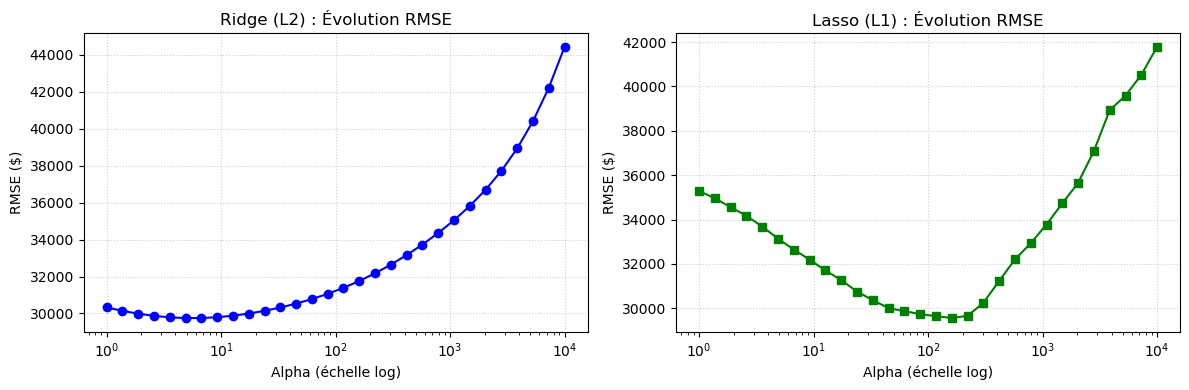

=== RÉSULTATS OBTENUS ===
Meilleur Alpha Ridge : 4.89 | RMSE Val : 51577.36 $
 -> Norme L2 des coefficients : 150410.95
Meilleur Alpha Lasso : 161.03 | RMSE Val : 47597.07 $
 -> Coefficients exactement NULS : 251 / 362
Ridge (L2) réduit progressivement la valeur de tous les coefficients pour lisser le modèle sans en éliminer aucun, tandis que Lasso (L1) annule complètement les coefficients inutiles, réalisant ainsi une sélection automatique des variables les plus importantes.


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

# 1. Chargement et split
X, y = fetch_openml(
    name="Ames_Housing", version=1, as_frame=True, return_X_y=True
)
y = y.astype(float)

X_rem, X_test, y_rem, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_rem, y_rem, test_size=0.1765, random_state=42
)

# 2. Prétraitement
true_num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

poly_cols = [
    c
    for c in true_num_cols
    if c.lower()
    in ["overall_qual", "gr_liv_area", "total_bsmt_sf", "1st_flr_sf", "garage_cars"]
]
if len(poly_cols) < 5:
    poly_cols = true_num_cols[:5]
num_cols = [c for c in true_num_cols if c not in poly_cols]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "poly",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                    ("scaler", StandardScaler()),
                ]
            ),
            poly_cols,
        ),
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            num_cols,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            cat_cols,
        ),
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)

# 3. Grille d'alpha ciblée
alphas = np.logspace(0, 4, 30)

# 4. Modèles ultrarapides (RidgeCV et LassoCV)
ridge = RidgeCV(alphas=alphas, store_cv_values=True)
ridge.fit(X_train_prep, y_train)

# max_iter bas et tolérance ajustée pour débloquer Lasso instantanément
lasso = LassoCV(
    alphas=alphas, max_iter=1000, tol=0.01, random_state=42, cv=3
)
lasso.fit(X_train_prep, y_train)

# 5. Calcul des erreurs sur Validation
rmse_ridge = np.sqrt(
    mean_squared_error(y_val, ridge.predict(X_val_prep))
)
rmse_lasso = np.sqrt(
    mean_squared_error(y_val, lasso.predict(X_val_prep))
)

norme_ridge = np.linalg.norm(ridge.coef_)
zeros_lasso = np.sum(lasso.coef_ == 0)
total_coefs = X_train_prep.shape[1]

# 6. Affichage des courbes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Courbe Ridge
axes[0].plot(
    alphas,
    np.sqrt(ridge.cv_values_.mean(axis=0)),
    color="blue",
    marker="o",
)
axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha (échelle log)")
axes[0].set_ylabel("RMSE ($)")
axes[0].set_title("Ridge (L2) : Évolution RMSE")
axes[0].grid(True, linestyle=":", alpha=0.6)

# Courbe Lasso
axes[1].plot(
    lasso.alphas_,
    np.sqrt(lasso.mse_path_.mean(axis=1)),
    color="green",
    marker="s",
)
axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha (échelle log)")
axes[1].set_ylabel("RMSE ($)")
axes[1].set_title("Lasso (L1) : Évolution RMSE")
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# Résultats imprimés
print("=== RÉSULTATS OBTENUS ===")
print(
    f"Meilleur Alpha Ridge : {ridge.alpha_:.2f} | RMSE Val : {rmse_ridge:.2f} $"
)
print(f" -> Norme L2 des coefficients : {norme_ridge:.2f}")
print(
    f"Meilleur Alpha Lasso : {lasso.alpha_:.2f} | RMSE Val : {rmse_lasso:.2f} $"
)
print(
    f" -> Coefficients exactement NULS : {zeros_lasso} / {total_coefs}"
)
print("Ridge (L2) réduit progressivement la valeur de tous les coefficients pour lisser le modèle sans en éliminer aucun, tandis que Lasso (L1) annule complètement les coefficients inutiles, réalisant ainsi une sélection automatique des variables les plus importantes.")

## Stress test — 10 pts

Votre modèle final doit subir un stress test.

Identifiez les **10 plus grandes erreurs absolues** sur VALIDATION. Pour au moins 3 maisons, comparez leurs caractéristiques à celles d'observations typiques et proposez une hypothèse expliquant l'erreur.

Une simple liste de prix réels/prédits ne suffit pas.

In [ ]:
Print("Pas vue en cours")

## Décision finale & TEST — 10 pts

Figez votre modèle et vos hyperparamètres **avant** d'ouvrir TEST. Évaluez une seule fois sur TEST.

Présentez MSE, RMSE, R² et une comparaison VALIDATION/TEST. Expliquez si la généralisation est cohérente avec ce que vous aviez anticipé.

Terminez par une recommandation technique de 10 lignes maximum.

## Reproductibilité & intégrité — 5 pts

### Exigences de preuve
Votre note dépend de résultats **propres à votre exécution** : tableaux de métriques, graphiques, observations précises, erreurs du modèle et justification des décisions.  
Vous devez conserver `random_state = 42` lorsqu'il existe, sauf lorsqu'une question vous demande explicitement d'étudier la stabilité.

### Ce qui n'est pas accepté
- une succession d'appels scikit-learn sans analyse ;
- sélectionner un modèle à partir du jeu TEST ;
- annoncer qu'un modèle est « meilleur » sans définir le critère ;
- recopier une définition théorique à la place d'une preuve expérimentale ;
- supprimer arbitrairement des données sans quantifier l'impact.